# Module 6: Tree-Based Methods and the Classifier Comparison

## **Problem 4: Classifier Shootout**

You will now apply every classifier from Modules 4–6 to the Ising model phase classification problem from Module 5. This is the same dataset used in the neural network lectures — each sample is a $10 \times 10$ spin configuration, and the label is ordered ($0$) versus disordered ($1$).

- Generate the data using the `generate_ising_dataset` function from lecture (or load the saved `.npz` file).  
- Use $400$ samples per phase.  
- Split the dataset into training and testing sets using a $70/30$ split with `random_state = 0`.

---

### A. Train All Classifiers

Fit each of the following classifiers to the Ising training data:

1. Logistic regression (`LogisticRegression`, `max_iter = 1000`)  
2. k-Nearest Neighbors (`KNeighborsClassifier`, $k = 5$)  
3. Decision tree (`DecisionTreeClassifier`, `max_depth = 5`)  
4. Random forest (`RandomForestClassifier`, $200$ trees)  
5. Gradient boosting (`GradientBoostingClassifier`, $200$ trees, `max_depth = 3`, learning rate $= 0.1$)  
6. Neural network (use your PyTorch FlexNet from Module 5, hidden layers $[64, 32]$, ReLU activation, $150$ epochs)

For Each Classifier, Report:

- Test accuracy  
- AUC (area under the ROC curve)  
- Training time (use `time.time()`)

---

In [25]:
### IMPORTS

import numpy as np
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

In [2]:
### FUNCTIONS FROM LECTURE

def ising_monte_carlo(L, T, n_steps=5000, rng=None):
    """Metropolis Monte Carlo for 2D Ising model."""
    if rng is None:
        rng = np.random.default_rng()
    spins = rng.choice([-1, 1], size=(L, L))
    for step in range(n_steps):
        i, j = rng.integers(0, L, size=2)
        neighbors = (
            spins[(i+1) % L, j] + spins[(i-1) % L, j] +
            spins[i, (j+1) % L] + spins[i, (j-1) % L]
        )
        dE = 2 * spins[i, j] * neighbors
        if dE <= 0 or rng.random() < np.exp(-dE / T):
            spins[i, j] *= -1
    return spins


def generate_ising_dataset(L=10, n_samples_per_phase=500, n_mc_steps=10000, rng=None):
    """Generate labeled Ising configurations: ordered (0) vs disordered (1)."""
    if rng is None:
        rng = np.random.default_rng()
    T_c = 2.269
    T_low = rng.uniform(1.0, 1.8, size=n_samples_per_phase)
    T_high = rng.uniform(2.8, 4.0, size=n_samples_per_phase)
    
    configs, labels, temps = [], [], []
    for T in T_low:
        spins = ising_monte_carlo(L, T, n_steps=n_mc_steps, rng=rng)
        configs.append(spins.flatten()); labels.append(0); temps.append(T)
    for T in T_high:
        spins = ising_monte_carlo(L, T, n_steps=n_mc_steps, rng=rng)
        configs.append(spins.flatten()); labels.append(1); temps.append(T)
    
    X = np.array(configs, dtype=np.float32)
    y = np.array(labels, dtype=np.float32)
    T_arr = np.array(temps)
    idx = rng.permutation(len(y))
    return X[idx], y[idx], T_arr[idx]

In [12]:
# generate data (takes a while)
X, y, T = generate_ising_dataset(L=10, n_samples_per_phase=400)

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

In [13]:
### HELPER FUNCTION
def evaluate_model(model, X_train, X_test, y_train, y_test, name="Model"):
    start = time.time()
    
    model.fit(X_train, y_train)
    
    train_time = time.time() - start
    
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_score)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "AUC": auc,
        "Train Time (s)": train_time
    })

In [7]:
### FLEXNET
class FlexNet(nn.Module):
    """
    Flexible feedforward network.
    
    hidden_sizes: list of ints, e.g. [32, 16] for 2 hidden layers
    activation: 'sigmoid', 'relu', or 'tanh'
    """
    def __init__(self, input_dim, hidden_sizes, activation='relu'):
        super().__init__()
        
        act_map = {'sigmoid': nn.Sigmoid, 'relu': nn.ReLU, 'tanh': nn.Tanh}
        act_fn = act_map[activation]
        
        layers = []
        prev_dim = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(act_fn())
            prev_dim = h
        layers.append(nn.Linear(prev_dim, 1))
        layers.append(nn.Sigmoid())  # output probability
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x).squeeze(-1)


In [23]:
### TRAIN MODELS
results = []

# logistic regression
log_reg = LogisticRegression(max_iter=1000)
evaluate_model(log_reg, X_train, X_test, y_train, y_test, "Logistic Regression")

# knn (k=5)
knn = KNeighborsClassifier(n_neighbors=5)
evaluate_model(knn, X_train, X_test, y_train, y_test, "k-NN (k=5)")

# decision tree
tree = DecisionTreeClassifier(max_depth=5)
evaluate_model(tree, X_train, X_test, y_train, y_test, "Decision Tree")

# random forest
rf = RandomForestClassifier(n_estimators=200)
evaluate_model(rf, X_train, X_test, y_train, y_test, "Random Forest")

# gradient boosting
gb = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1
)
evaluate_model(gb, X_train, X_test, y_train, y_test, "Gradient Boosting")

# pytorch flex net
nn_model = FlexNet(
    input_dim=100,
    hidden_sizes=[64, 32],
    activation='relu'
)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.float32)

criterion = nn.BCELoss()
optimizer = optim.Adam(nn_model.parameters(), lr=1e-3)

start = time.time()

for epoch in range(150):
    optimizer.zero_grad()
    
    outputs = nn_model(X_train_t)
    loss = criterion(outputs, y_train_t)
    
    loss.backward()
    optimizer.step()

train_time = time.time() - start

with torch.no_grad():
    probs = nn_model(X_test_t).numpy()
    preds = (probs > 0.5).astype(int)

acc = accuracy_score(y_test, preds)
auc = roc_auc_score(y_test, probs)

results.append({
    "Model": "Neural Network (FlexNet)",
    "Accuracy": acc,
    "AUC": auc,
    "Train Time (s)": train_time
})

In [21]:
### CREATE TABLE
import pandas as pd

df = pd.DataFrame(results)
df = df.round({
    "Accuracy": 3,
    "AUC": 3,
    "Train Time (s)": 3
})

# sort by accuracy
df = df.sort_values(by="Accuracy", ascending=False)

df

,Model,Accuracy,AUC,Train Time (s)
3,Random Forest,0.996,1.000,0.252
4,Gradient Boosting,0.992,1.000,0.365
5,Neural Network (FlexNet),0.988,1.000,0.165
2,Decision Tree,0.942,0.933,0.010
1,k-NN (k=5),0.871,0.930,0.001
0,Logistic Regression,0.704,0.560,0.016


## B. ROC Curves
Plot the ROC curve for all six classifiers on a single set of axes, with AUC
values in the legend.

---

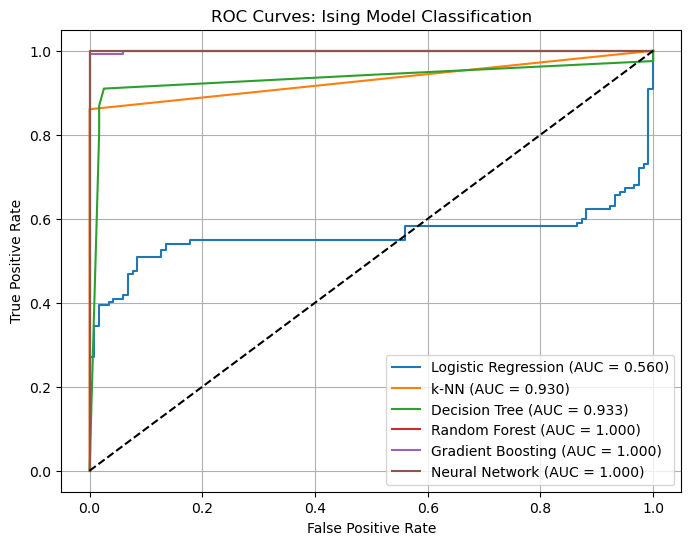

In [27]:
from sklearn.metrics import roc_curve, auc as sk_auc

roc_data = {}

models = {
    "Logistic Regression": log_reg,
    "k-NN": knn,
    "Decision Tree": tree,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for name, model in models.items():
    
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_data[name] = (fpr, tpr, sk_auc(fpr, tpr))


with torch.no_grad():
    y_score = nn_model(X_test_t).numpy()

fpr, tpr, _ = roc_curve(y_test, y_score)
roc_data["Neural Network"] = (fpr, tpr, sk_auc(fpr, tpr))

plt.figure(figsize=(8, 6))

for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

# diagonal reference line (random classifier)
plt.plot([0, 1], [0, 1], linestyle='--', color='black')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves: Ising Model Classification")
plt.legend()
plt.grid(True)

plt.show()

## C. Engineered features

Add three hand-crafted features to the raw spin data:

- Signed magnetization:
  $$
  M = \frac{1}{N}\sum_i s_i
  $$

- Absolute magnetization:
  $$
  |M|
  $$

- Nearest-neighbor energy:
  $$
  E = -\frac{1}{N_{\text{bonds}}} \sum_{\langle i,j\rangle} s_i s_j
  $$

### Tasks

1. Retrain **logistic regression** and **gradient boosting** on the augmented feature set (103 features).

2. Report the new accuracies and compare to part (a).

3. For gradient boosting:
   - Plot the top-15 feature importance bar chart.
   - Determine whether $|M|$ dominates.

What does this tell you about what the tree-based method “discovered” from the raw spins?

---

Logistic Regression (engineered):
Accuracy: 0.9917
AUC: 0.999

Gradient Boosting (engineered):
Accuracy: 0.9958
AUC: 0.9959


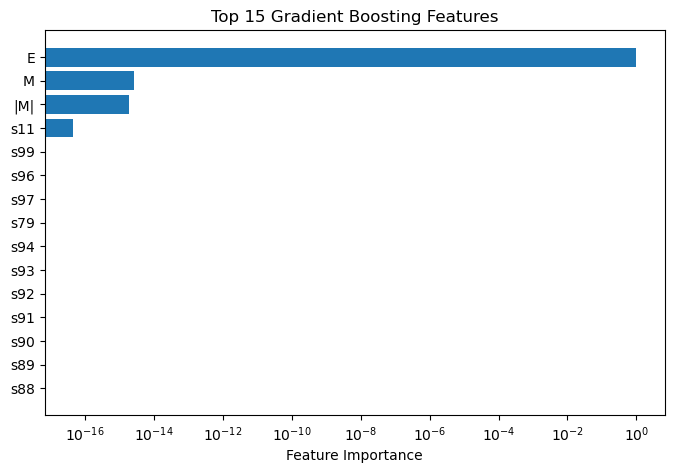

In [31]:
L = 10
N = L * L

# feature engineering
def engineer_features(X):
    features = []

    for x in X:
        spins = x.reshape(L, L)

        # magnetization
        M = np.mean(spins)

        # absolute magnetization
        absM = np.abs(M)

        # nearest-neighbor energy
        E = 0
        for i in range(L):
            for j in range(L):
                S = spins[i, j]
                E -= S * (
                    spins[(i+1) % L, j] +
                    spins[i, (j+1) % L]
                )
        E /= N

        features.append(np.concatenate([x, [M, absM, E]]))

    return np.array(features, dtype=np.float32)


# apply feature engineering
X_train_feat = engineer_features(X_train)
X_test_feat  = engineer_features(X_test)

feature_names = [f"s{i}" for i in range(100)] + ["M", "|M|", "E"]


# logistic regression
log_reg_feat = LogisticRegression(max_iter=1000)
log_reg_feat.fit(X_train_feat, y_train)

y_pred_log = log_reg_feat.predict(X_test_feat)
y_score_log = log_reg_feat.predict_proba(X_test_feat)[:, 1]

acc_log = accuracy_score(y_test, y_pred_log)
auc_log = roc_auc_score(y_test, y_score_log)


# gradient boosting
gb_feat = GradientBoostingClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.1
)

gb_feat.fit(X_train_feat, y_train)

y_pred_gb = gb_feat.predict(X_test_feat)
y_score_gb = gb_feat.predict_proba(X_test_feat)[:, 1]

acc_gb = accuracy_score(y_test, y_pred_gb)
auc_gb = roc_auc_score(y_test, y_score_gb)


# comparison
print("Logistic Regression (engineered):")
print("Accuracy:", round(acc_log,4))
print("AUC:", round(auc_log,4))

print("\nGradient Boosting (engineered):")
print("Accuracy:", round(acc_gb,4))
print("AUC:", round(auc_gb,4))


# plot
importances = gb_feat.feature_importances_
idx = np.argsort(importances)[-15:]

plt.figure(figsize=(8, 5))
plt.barh([feature_names[i] for i in idx], importances[idx])
plt.semilogx()
plt.xlabel("Feature Importance")
plt.title("Top 15 Gradient Boosting Features")
plt.show()

Without being told physics, the tree-based model "discovered" that the nearest neighbor energy is its most effective method of distinguishing between phases. Perhaps naively, I would expect it to find magnetization most useful, but it used E almost exclusively.

---

### D. Discussion

1. Which classifier performed best on raw spins? With engineered features?

On the raw spin data,  gradient boosting and random forest performed best. With engineered features, logistic regression got significantly better and gradient boosting still performed well. The main effect of feature engineering was to close the gap between simple and complex models rather than dramatically improve the best model.

---

2. When is it worth engineering features by hand vs letting the model figure it out?

Feature engineering is most valuable when using simpler or data-limited models, where incorporating domain knowledge can significantly improve performance. In contrast, flexible models like tree ensembles or neural networks can often learn effective features directly from raw data, especially when sufficient data is available. However, engineered features can still improve interpretability and reduce the learning burden even for complex models.

---

3. If you were analyzing data from a real experiment and had to choose one classifier as your default starting point, which would you choose and why?

I would choose a tree-based ensemble like gradient boosting as a default starting point. It handles nonlinear relationships and feature interactions, requires minimal preprocessing, and provides useful feature importance measures for interpretation.

---

